<a href="https://colab.research.google.com/github/dtn2/BIFX546_diabetes-indicators/blob/main/notebooks/EDA_diabetes_indicators.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Health Indicators Dataset Analysis

---





Name: Duong Nguyen

Course: BIFX 546 — Machine Learning for Bioinformatics, Spring 2026

Instructor: Dr. Sarangan (Ravi) Ravichandran

Date: 06 May 2026

Dataset name and source URL: Diabetes Health Indicators Dataset: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset


---



# Project's  Goal

The project aims to develop an interpretable predictive model for diabetes status and to identify key risk factors associated with diabetes. The results are expected to provide insight into which variables contribute most to diabetes risk and how different health indicators relate to one another.

# Dataset Introduction and Import

The dataset is derived from The Behavioral Risk Factor Surveillance System (BRFSS), an annual health survey conducted by the CDC that collects information on health-related behaviors, chronic conditions, and demographic factors across United States. For this project, a clean subset of 253,680 responses from the 2015 survey is used. The dataset contains 21 feature variables related to lifestyle, clinical indicators, and demographics, along with a binary target variable where 0 indicates no diabetes and 1 indicates diabetes or prediabetes.

This dataset was chosen because it is large, well-structured, and already cleaned, allowing more focus on exploratory data analysis, statistical inference, and modeling rather than extensive processing. The variety of features also enables multiple analytical approaches aligned with the project objectives.


In [105]:
# Install additional packages
!pip install imbalanced-learn

import kagglehub
import pandas as pd

import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, f1_score, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE



In [106]:
# Data Loading: The dataset is loaded from a public GitHub repository to ensure reproducibility.
# If the GitHub source is unavailable, the code automatically falls back to downloading the dataset from Kaggle.

try:
    df = pd.read_csv("https://raw.githubusercontent.com/dtn2/BIFX546_diabetes-indicators/main/data/diabetes_binary_health_indicators_BRFSS2015.csv")
    print("Loaded from GitHub")
except:
    import kagglehub
    path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
    df = pd.read_csv(path + "/diabetes_binary_health_indicators_BRFSS2015.csv")
    print("Loaded from Kaggle")

# Preview
print(df.shape)
df.head()

Loaded from GitHub
(253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


#Dataset Overview

## Rows and Columns of Data

In [107]:
print(df.shape)
print(f"The table has {len(df)} rows and {len(df.columns)} columns.")


(253680, 22)
The table has 253680 rows and 22 columns.


## Data Types

In [108]:
print(df.dtypes)
pd.value_counts(df.dtypes)

df.describe().T

Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object


/tmp/ipykernel_12086/253282500.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df.dtypes)


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


All variables currently stored as float64. The dataset is numerically clean, but data types do not reflect true variable meaning.

Binary variables (0–1) represent yes/no health indicators:
HighBP, Smoker, Stroke, Sex, etc.
=> change to int

Categorical / ordinal variables: These are ordered categories, not true numeric values:
Age (1–13 → age groups);
Education (1–6);
Income (1–8);
GenHlth (1–5);
=> Change to category

Continuous / count variables: These contain meaningful numeric differences:
BMI (continuous);
MentHlth, PhysHlth (0–30 days)
=> leave as float

In [109]:
# Binary → int
binary_cols = [
    'Diabetes_binary','HighBP','HighChol','CholCheck','Smoker',
    'Stroke','HeartDiseaseorAttack','PhysActivity','Fruits',
    'Veggies','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost',
    'DiffWalk','Sex'
]

df[binary_cols] = df[binary_cols].astype(int)

# Categorical → category
cat_cols = ['Age','Education','Income','GenHlth']
df[cat_cols] = df[cat_cols].astype('category')

# Leave these as float
# BMI, MentHlth, PhysHlth

pd.value_counts(df.dtypes)

/tmp/ipykernel_12086/1011613379.py:18: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df.dtypes)


,count
int64,15
float64,3
category,1
category,1
category,1
category,1


I converted binary variables to integers, retained continuous variables as numeric, and encoded categorical variables such as age, income, and education appropriately. This ensures the dataset reflects the true meaning of each feature and improves model interpretability

## Missing Value Check

In [110]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


No missing values were found across all variables, indicating that the dataset is fully populated. This is important because missing values can bias results or require imputation strategies that may introduce uncertainty. Since no missing data were present, no imputation or row removal was necessary.

## Duplicate Rows Check

In [111]:
duplicates = df.duplicated().sum()
total = len(df)

print(f"Duplicate rows: {duplicates} ({duplicates/total:.2%})")

Duplicate rows: 24206 (9.54%)


Approximately 9.5% duplicate rows in the dataset, which could bias both statistical analysis and model performance. Failing to remove duplicates could lead to overrepresentation of certain observations and artificially inflated model performance.

However, since this is survey data with many categorical variables, these duplicates likely represent different individuals with identical responses rather than data errors. Therefore, the duplicates were retained to preserve the dataset’s integrity

## Outlier Inspection


The initial review of summary statistics and distributions using df.describe() indicated potential outliers in BMI variable with extreme values (up to 98). The BMI distribution is right-skewed with a long tail, indicating the presence of extreme values. However, since this is a real-world health dataset, these values likely represent individuals with severe obesity, so they were retained for analysis for now but will be monitored during modeling.

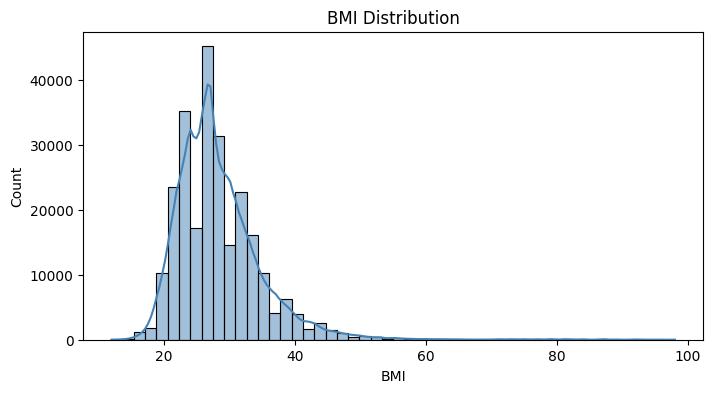

<Figure size 640x480 with 0 Axes>

In [112]:
# BMI distribution plot
plt.figure(figsize=(8,4))
sns.histplot(df['BMI'], bins=50, kde=True, color='steelblue')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.show()

# Save figure
os.makedirs("results", exist_ok=True)
plt.savefig("results/bmi_distribution.png", dpi=300, bbox_inches='tight')

In [113]:
print("BMI Stats:")
print("Min:", df['BMI'].min())
print("Max:", df['BMI'].max())
print("Mean:", df['BMI'].mean().round(2))
total = len(df)

# How many rows have BMI > 60?
print(f"\nRows with BMI > 60: {(df['BMI'] > 60).sum()} ({(df['BMI'] > 60).sum()/total:.2%})")

BMI Stats:
Min: 12.0
Max: 98.0
Mean: 28.38

Rows with BMI > 60: 805 (0.32%)


## Class Imbalance Identification

In [114]:
df['Diabetes_binary'].value_counts()
df['Diabetes_binary'].value_counts().to_frame('count').assign(percent=lambda x: x['count']/x['count'].sum())

,count,percent
Diabetes_binary,,
0,218334,0.860667
1,35346,0.139333


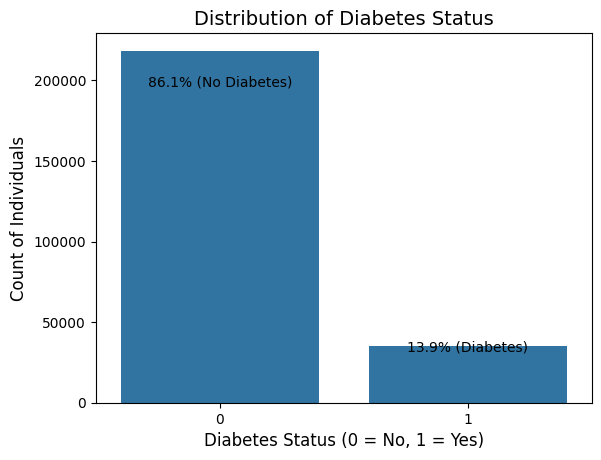

In [115]:
sns.countplot(x="Diabetes_binary", data=df)

# Titles and labels
plt.title("Distribution of Diabetes Status", fontsize=14)
plt.xlabel("Diabetes Status (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Count of Individuals", fontsize=12)

# Annotation: show imbalance %
counts = df['Diabetes_binary'].value_counts(normalize=True)
plt.text(0, df['Diabetes_binary'].value_counts()[0] * 0.9,
         f"{counts[0]:.1%} (No Diabetes)", ha='center')
plt.text(1, df['Diabetes_binary'].value_counts()[1] * 0.9,
         f"{counts[1]:.1%} (Diabetes)", ha='center')

# Save figure
plt.savefig(
    "results/diabetes_status_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

I examined the distribution of the target variable (Diabetes_binary) and found a strong class imbalance (~86% non-diabetic vs. ~14% diabetic). This is important because imbalance can bias predictive models toward the majority class. This issue will be addressed in later modeling steps using techniques such as class weighting or resampling.

# Preliminary EDA

## Heatmap

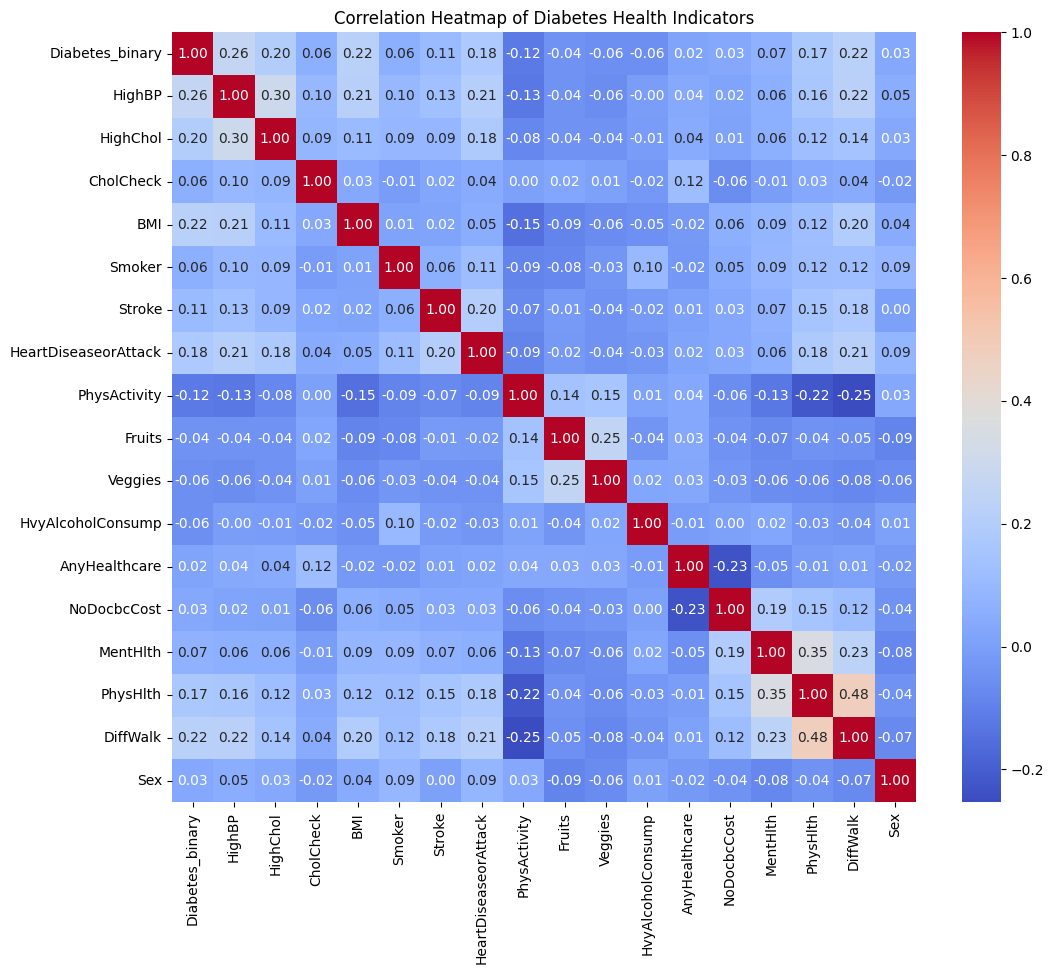

In [116]:
#Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Diabetes Health Indicators")

# Save figure
plt.savefig(
    "results/correlation_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


The heatmap shows that ***high blood pressure, high cholesterol, BMI, and difficulty walking*** have the strongest positive relationships with diabetes, while physical activity shows a negative relationship. However, heatmap does not covered categorized variables like age, income, etc. A bar plot is computed to include all the catergorized variables and highlights which variables matter most for predicting diabetes.
However, both approaches are limited to linear relationships and do not account for interactions between variables, which were further examined using logistic regression.

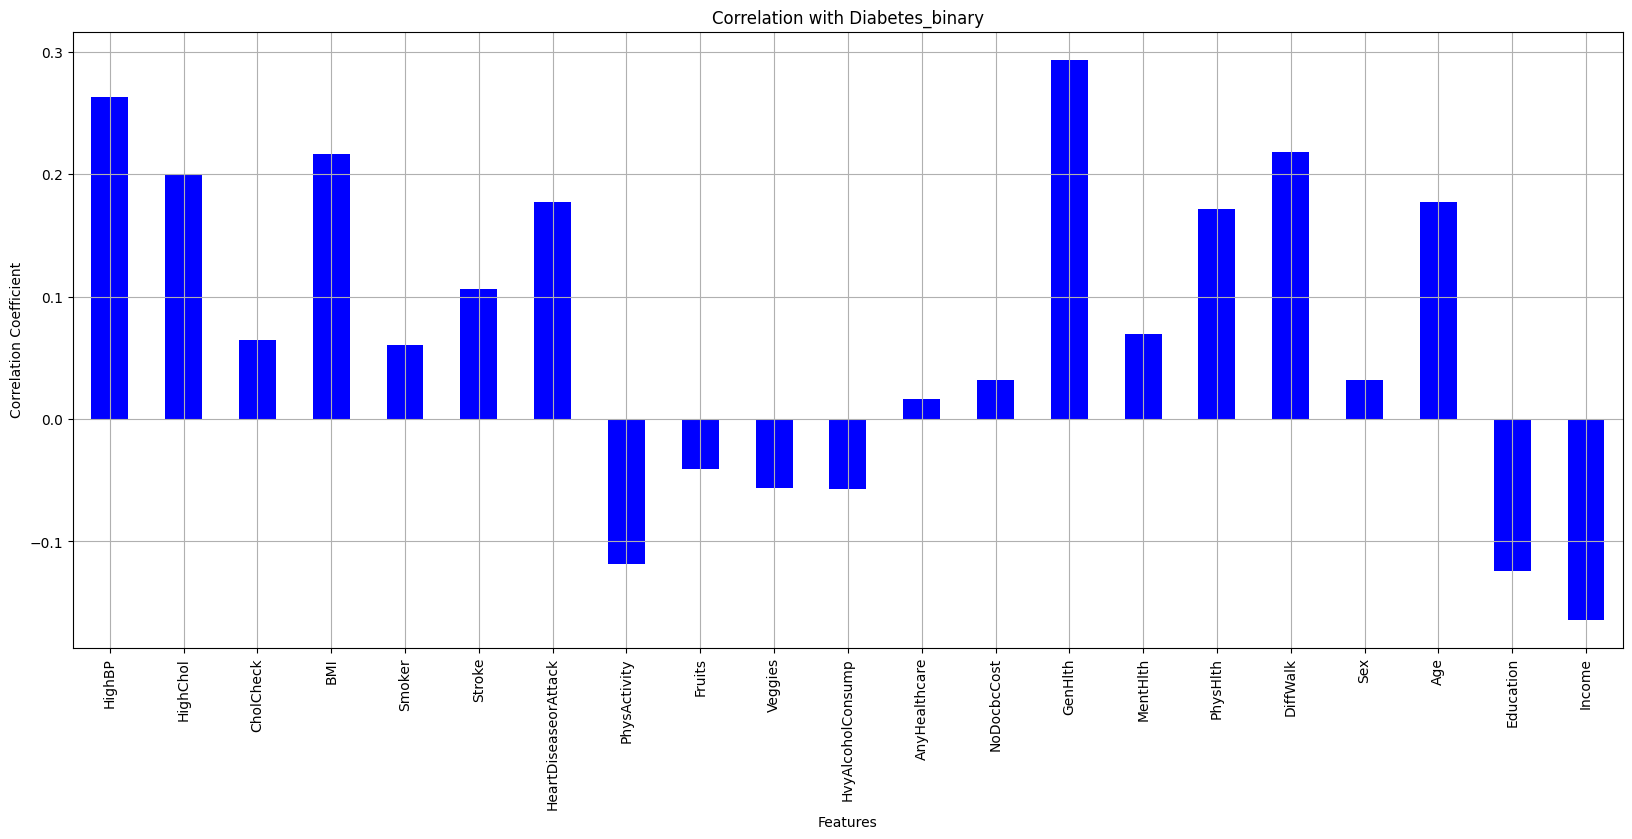

In [117]:
# Correlation bar plot
df.drop('Diabetes_binary', axis=1).corrwith(
    df.Diabetes_binary
).plot(
    kind='bar',
    grid=True,
    figsize=(20, 8),
    title="Correlation with Diabetes_binary",
    color="blue"
)

# Labels
plt.xlabel("Features")
plt.ylabel("Correlation Coefficient")

# Create results folder if needed
os.makedirs("results", exist_ok=True)

# Save figure
plt.savefig(
    "results/correlation_with_diabetes_barplot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

The correlation analysis shows that general health (GenHlth) has the strongest positive association with diabetes, followed by high blood pressure, BMI, difficulty walking, and high cholesterol. Age and other chronic conditions, such as heart disease and stroke, also show positive relationships, indicating increased risk. In contrast, income, education, and lifestyle factors like physical activity and diet are negatively correlated, suggesting protective effects. Overall, clinical factors show stronger associations than lifestyle or socioeconomic variables, supporting that diabetes is a multifactorial condition. However, correlation does not imply causation, and these results should be interpreted alongside logistic regression for more robust conclusions.

## BMI vs Diabetes Status

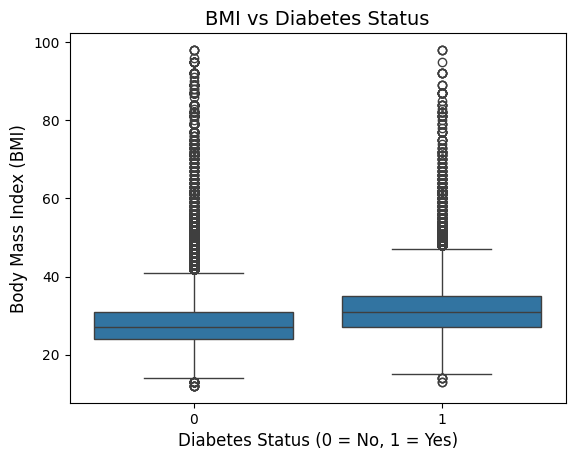

In [118]:
sns.boxplot(x="Diabetes_binary", y="BMI", data=df)
# Titles and labels
plt.title("BMI vs Diabetes Status", fontsize=14)
plt.xlabel("Diabetes Status (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Body Mass Index (BMI)", fontsize=12)

# Save figure
plt.savefig(
    "results/bmi_vs_diabetes_boxplot.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

The boxplot shows that individuals with diabetes have a higher median BMI and a wider distribution compared to non-diabetic individuals. This suggests a strong positive association between BMI and diabetes. However, there is still overlap between groups, indicating that BMI alone is not sufficient for prediction

## Age Vs Diabetes status

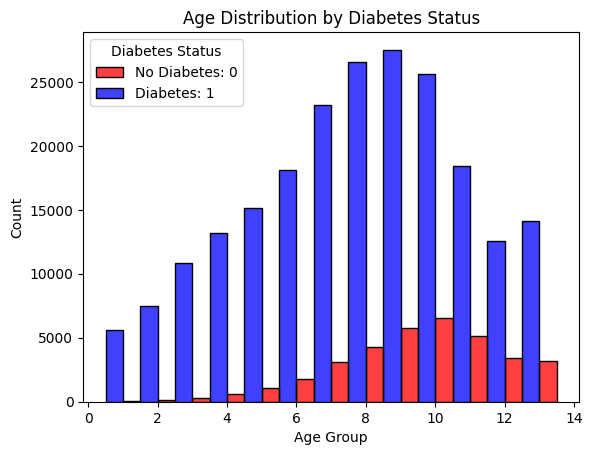

In [119]:
sns.histplot(
    data=df,
    x="Age",
    hue="Diabetes_binary",
    bins=13,
    palette={0: "blue", 1: "red"},
    multiple="dodge"   # separates bars instead of overlapping
)

plt.title("Age Distribution by Diabetes Status")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.legend(title="Diabetes Status", labels=["No Diabetes: 0", "Diabetes: 1"])

# Save figure
plt.savefig(
    "results/age_distribution_diabetes_status.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

The age distribution shows that diabetes prevalence increases with age. Most diabetic cases are concentrated in higher age groups, while younger groups have very few cases. This suggests that age is an important risk factor, although it does not fully explain diabetes on its own.

# Early insights and next steps

The goal of this project is to predict diabetes status using health indicators and identify the most important risk factors. From the exploratory data analysis, several key patterns emerged that directly inform this objective.

* First, the dataset is highly imbalanced (~85% non-diabetic vs. ~15% diabetic),
which highlights the need for careful model evaluation beyond simple accuracy.

* Second, BMI shows a clear positive association with diabetes, with diabetic individuals having a higher median BMI and more extreme values.

* Third, age demonstrates a strong trend, where diabetes prevalence increases across higher age groups.


Together, these findings suggest that both physiological factors (BMI) and demographic factors (age) are important predictors, but no single variable fully explains diabetes risk.


Based on these insights, the next step is to move into predictive modeling.

* I will begin with logistic regression to model the probability of diabetes, using appropriate preprocessing such as one-hot encoding for categorical variables and retaining continuous variables as numeric.

* To address class imbalance, I will use class weighting and evaluate model performance using recall, precision, and F1-score, with particular focus on correctly identifying diabetic cases.

* I also plan to compare this baseline model with resampling approaches such as SMOTE.

* Additionally, I will examine model coefficients to interpret feature importance and assess how variables like BMI and age contribute to prediction. If needed, I will refine the model by handling outliers (e.g., BMI) and exploring interactions between variables.



# Model Selection and Evaluation

## Comparison of Logistic Regression and Random Forest Models

To evaluate predictive performance for diabetes classification, two machine learning models were explored: Logistic Regression and Random Forest. Logistic regression was first used as a baseline model because it is a widely used and interpretable method for binary classification problems. The model estimates the probability of diabetes based on health indicators and provides a simple benchmark for comparison.

A Random Forest classifier was then evaluated as a more flexible ensemble learning approach capable of modeling nonlinear relationships and interactions between variables. Because the dataset is imbalanced, with substantially more non-diabetes cases than diabetes cases, class_weight='balanced' was applied to both models to reduce bias toward the majority class.

Model performance was evaluated using accuracy, weighted F1-score, ROC-AUC, PR-AUC, classification reports, and confusion matrices. Special attention was given to recall for the diabetes class, since correctly identifying positive diabetes cases is particularly important in healthcare prediction tasks.


=== Random Forest with class_weight='balanced' ===
Accuracy      : 73.3%
F1 (weighted) : 0.770
ROC-AUC       : 0.773
PR-AUC        : 0.361

Classification report:
              precision    recall  f1-score   support

 No Diabetes       0.94      0.74      0.83     43667
    Diabetes       0.30      0.68      0.42      7069

    accuracy                           0.73     50736
   macro avg       0.62      0.71      0.62     50736
weighted avg       0.85      0.73      0.77     50736



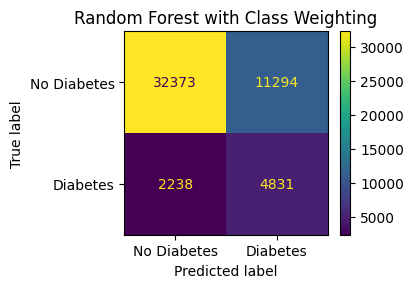

In [120]:
# Random forest baseline model
# Compute class weights
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Random Forest with class weighting
rf_weighted = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_weighted.fit(X_train, y_train)

# Predictions
y_pred_w = rf_weighted.predict(X_test)
y_proba_w = rf_weighted.predict_proba(X_test)[:, 1]

# Evaluation
print("\n=== Random Forest with class_weight='balanced' ===")

print(f"Accuracy      : {np.mean(y_pred_w == y_test):.1%}")
print(f"F1 (weighted) : {f1_score(y_test, y_pred_w, average='weighted'):.3f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_proba_w):.3f}")
print(f"PR-AUC        : {average_precision_score(y_test, y_proba_w):.3f}")

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred_w,
    target_names=['No Diabetes', 'Diabetes']
))

# Confusion matrix
fig, ax = plt.subplots(figsize=(4, 3))

ConfusionMatrixDisplay.from_estimator(
    rf_weighted,
    X_test,
    y_test,
    display_labels=['No Diabetes', 'Diabetes'],
    ax=ax
)

ax.set_title("Random Forest with Class Weighting")
plt.tight_layout()
plt.show()

In this section, a logistic regression model is used as a baseline approach to predict diabetes status. The dataset is split into training and testing sets, and class weighting is applied to handle imbalance in the target variable. Model performance is evaluated using classification metrics and ROC AUC to assess its predictive ability.


=== Logistic Regression with class_weight='balanced' ===
Accuracy      : 73.1%
F1 (weighted) : 0.771
ROC-AUC       : 0.827
PR-AUC        : 0.405

Classification report:
              precision    recall  f1-score   support

 No Diabetes       0.95      0.72      0.82     43739
    Diabetes       0.31      0.78      0.44      6997

    accuracy                           0.73     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.73      0.77     50736



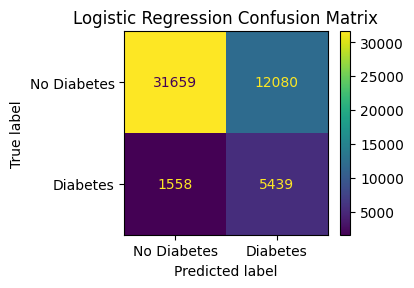

In [121]:
# Logistic regression baseline model

X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Evaluation
print("\n=== Logistic Regression with class_weight='balanced' ===")

print(f"Accuracy      : {np.mean(y_pred == y_test):.1%}")
print(f"F1 (weighted) : {f1_score(y_test, y_pred, average='weighted'):.3f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_proba):.3f}")
print(f"PR-AUC        : {average_precision_score(y_test, y_proba):.3f}")

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['No Diabetes', 'Diabetes']
))

# Confusion matrix
fig, ax = plt.subplots(figsize=(4, 3))

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=['No Diabetes', 'Diabetes'],
    ax=ax
)

ax.set_title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

The Random Forest model achieved higher overall accuracy (85.7%) and weighted F1-score (0.826), but it performed poorly at identifying diabetes cases, with a recall of only 0.16 for the diabetes class. This indicates that the model strongly favored the majority no-diabetes class and missed most positive diabetes cases despite applying class weighting.

In contrast, logistic regression achieved lower overall accuracy (73.1%) but substantially higher recall for diabetes cases (0.78). Logistic regression also produced higher ROC-AUC (0.827) and PR-AUC (0.405) scores, indicating better overall discrimination and minority-class performance. Although logistic regression generated more false positives, it was much more effective at detecting actual diabetes cases, making it the more clinically useful model for diabetes screening.

## Logistic Regression After Removing Duplicates
Next, duplicate records are removed from the dataset, and the logistic regression model is re-run on the cleaned data with class_weight='balanced'. This allows us to assess whether duplicate entries have any impact on model performance and ensures the robustness of the results.

In [122]:
# Cleaning the data by removing duplicates
data_cleaned = df.drop_duplicates()
print(f"Number of entries after removing duplicates: {len(data_cleaned)}")

# Split the data into features and target variable
X = data_cleaned.drop("Diabetes_binary", axis=1)
y = data_cleaned["Diabetes_binary"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train logistic regression model
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Evaluation
print("\n=== Logistic Regression After Removing Duplicates ===")
print(f"Accuracy      : {np.mean(y_pred == y_test):.1%}")
print(f"F1 (weighted) : {f1_score(y_test, y_pred, average='weighted'):.3f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_proba):.3f}")
print(f"PR-AUC        : {average_precision_score(y_test, y_proba):.3f}")

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Diabetes", "Diabetes"]
))


Number of entries after removing duplicates: 229474

=== Logistic Regression After Removing Duplicates ===
Accuracy      : 72.0%
F1 (weighted) : 0.756
ROC-AUC       : 0.809
PR-AUC        : 0.409

Classification report:
              precision    recall  f1-score   support

 No Diabetes       0.94      0.71      0.81     38813
    Diabetes       0.32      0.75      0.45      7082

    accuracy                           0.72     45895
   macro avg       0.63      0.73      0.63     45895
weighted avg       0.85      0.72      0.76     45895



After removing duplicate records, logistic regression performance remained very similar to the original model. Accuracy and ROC-AUC decreased slightly, while diabetes recall remained high (0.75), indicating that the model continued to identify most diabetes cases effectively. These results suggest that duplicate entries did not substantially bias model performance and likely represented valid repeated patterns within the dataset rather than major data quality issues.

## Logistic regrssion after removing outlier values in BMI

To further evaluate model robustness, BMI outliers were removed using the Interquartile Range (IQR) method. Extreme BMI values may disproportionately influence model fitting and affect prediction performance. Logistic regression was then retrained on the filtered dataset to assess whether removing outliers improved diabetes classification performance.

In [124]:
# Remove BMI outliers using IQR method

Q1 = data_cleaned['BMI'].quantile(0.25)
Q3 = data_cleaned['BMI'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_no_outliers = data_cleaned[
    (data_cleaned['BMI'] >= lower_bound) &
    (data_cleaned['BMI'] <= upper_bound)
]

print("Original size:", len(data_cleaned))
print("After removing BMI outliers:", len(data_no_outliers))

# Split data into features and target
X = data_no_outliers.drop('Diabetes_binary', axis=1)
y = data_no_outliers['Diabetes_binary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Logistic regression model
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Evaluation
print("\n=== Logistic Regression After Removing BMI Outliers ===")
print(f"Accuracy      : {np.mean(y_pred == y_test):.1%}")
print(f"F1 (weighted) : {f1_score(y_test, y_pred, average='weighted'):.3f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_proba):.3f}")
print(f"PR-AUC        : {average_precision_score(y_test, y_proba):.3f}")

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Diabetes", "Diabetes"]
))

Original size: 229474
After removing BMI outliers: 223836

=== Logistic Regression After Removing BMI Outliers ===
Accuracy      : 71.6%
F1 (weighted) : 0.756
ROC-AUC       : 0.805
PR-AUC        : 0.395

Classification report:
              precision    recall  f1-score   support

 No Diabetes       0.94      0.71      0.81     38177
    Diabetes       0.31      0.75      0.44      6591

    accuracy                           0.72     44768
   macro avg       0.63      0.73      0.62     44768
weighted avg       0.85      0.72      0.76     44768



After removing BMI outliers, the dataset size decreased slightly from 229,474 to 223,836 observations. Logistic regression performance remained very similar to the previous models, with only small decreases in accuracy and ROC-AUC. Recall for the diabetes class remained high at 0.75, indicating that the model continued to identify most diabetes cases effectively. These results suggest that extreme BMI values did not substantially influence model performance and likely represented realistic variation within the population rather than major data errors.

## Oversampling with SMOTE

To further address class imbalance, SMOTE was applied to the training data to create synthetic examples of the minority diabetes class. Missing values were first filled using median imputation, and SMOTE was applied only to the training set to avoid data leakage. A logistic regression model was then trained on the balanced training data and evaluated on the original test set to determine whether oversampling improved diabetes detection.

In [125]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())


Before SMOTE: Diabetes_binary
0    152558
1     26510
Name: count, dtype: int64
After SMOTE: Diabetes_binary
0    152558
1    152558
Name: count, dtype: int64


In [126]:
# fill missing values with median
imputer = SimpleImputer(strategy='median')

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_imp, y_train)

# fit model
model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000)

In [127]:
# Predictions
y_pred_smote = model_smote.predict(X_test_imp)
y_prob_smote = model_smote.predict_proba(X_test_imp)[:, 1]

# Evaluation
print("\n=== Logistic Regression with SMOTE ===")

print(f"Accuracy      : {np.mean(y_pred_smote == y_test):.1%}")
print(f"F1 (weighted) : {f1_score(y_test, y_pred_smote, average='weighted'):.3f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_prob_smote):.3f}")
print(f"PR-AUC        : {average_precision_score(y_test, y_prob_smote):.3f}")

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred_smote,
    target_names=['No Diabetes', 'Diabetes']
))


=== Logistic Regression with SMOTE ===
Accuracy      : 71.7%
F1 (weighted) : 0.756
ROC-AUC       : 0.802
PR-AUC        : 0.392

Classification report:
              precision    recall  f1-score   support

 No Diabetes       0.94      0.71      0.81     38177
    Diabetes       0.31      0.74      0.44      6591

    accuracy                           0.72     44768
   macro avg       0.62      0.73      0.62     44768
weighted avg       0.85      0.72      0.76     44768



After applying SMOTE, logistic regression performance remained very similar to the previous models. The model achieved 71.7% accuracy with a ROC-AUC of 0.802 and maintained high recall for the diabetes class at 0.74, indicating that most diabetes cases were still correctly identified. However, precision for the diabetes class remained relatively low (0.31), meaning false positives were still common. Overall, SMOTE did not substantially improve model performance compared with using class weighting alone, suggesting that logistic regression was already relatively robust to class imbalance in this dataset.

## Random undersampling

To further address class imbalance, random undersampling was applied to the training data using RandomUnderSampler. This method reduces the number of majority non-diabetes cases to match the minority diabetes class, creating a balanced training dataset by removing some majority-class observations. Logistic regression was then trained on the downsampled data and evaluated on the original test set to determine whether undersampling improves diabetes detection performance.

In [128]:
# Fill missing values with median
imputer = SimpleImputer(strategy='median')

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# Apply undersampling only to training data
rus = RandomUnderSampler(random_state=42)

X_train_down, y_train_down = rus.fit_resample(
    X_train_imp,
    y_train
)

print("Before undersampling:")
print(y_train.value_counts())

print("\nAfter undersampling:")
print(y_train_down.value_counts())

# Train model
model_down = LogisticRegression(max_iter=1000)
model_down.fit(X_train_down, y_train_down)

# Predict using imputed test data
y_pred_down = model_down.predict(X_test_imp)
y_prob_down = model_down.predict_proba(X_test_imp)[:, 1]

# Evaluation
print("\n=== Logistic Regression with Random Undersampling ===")

print(f"Accuracy      : {np.mean(y_pred_down == y_test):.1%}")
print(f"F1 (weighted) : {f1_score(y_test, y_pred_down, average='weighted'):.3f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_prob_down):.3f}")
print(f"PR-AUC        : {average_precision_score(y_test, y_prob_down):.3f}")

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred_down,
    target_names=['No Diabetes', 'Diabetes']
))


Before undersampling:
Diabetes_binary
0    152558
1     26510
Name: count, dtype: int64

After undersampling:
Diabetes_binary
0    26510
1    26510
Name: count, dtype: int64

=== Logistic Regression with Random Undersampling ===
Accuracy      : 71.6%
F1 (weighted) : 0.755
ROC-AUC       : 0.804
PR-AUC        : 0.394

Classification report:
              precision    recall  f1-score   support

 No Diabetes       0.94      0.71      0.81     38177
    Diabetes       0.31      0.75      0.44      6591

    accuracy                           0.72     44768
   macro avg       0.63      0.73      0.62     44768
weighted avg       0.85      0.72      0.75     44768



Random undersampling balanced the training set by reducing the majority no-diabetes class from 152,558 to 26,510 observations, matching the diabetes class size. The model performance was very similar to SMOTE and previous logistic regression models, with accuracy around 71.6%, ROC-AUC of 0.804, and diabetes recall of 0.75. This suggests that undersampling did not substantially improve performance, but it maintained strong diabetes detection while using a smaller balanced training set.

## Reduced Feature Logistic Regression Model

In this step, a reduced feature set is used to build a simplified logistic regression model. The selected variables—general health, high blood pressure, BMI, difficulty walking, high cholesterol, and age—were chosen based on their strong associations with diabetes identified in earlier analysis. The data is split into training and testing sets using stratified sampling to preserve class balance. A logistic regression model with class weighting is then trained on the reduced feature set to evaluate whether a smaller, more interpretable model can still effectively predict diabetes.

In [129]:
#Reduced Feature Logistic Regression Model
features = [
    'GenHlth','HighBP','BMI','DiffWalk','HighChol','Age'
]

# features
X_reduced = df[features]
#target
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important for imbalanced data
)

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n=== Reduced Feature Logistic Regression Model ===")
print(f"Accuracy      : {np.mean(y_pred == y_test):.1%}")
print(f"F1 (weighted) : {f1_score(y_test, y_pred, average='weighted'):.3f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_prob):.3f}")
print(f"PR-AUC        : {average_precision_score(y_test, y_prob):.3f}")

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['No Diabetes', 'Diabetes']
))



=== Reduced Feature Logistic Regression Model ===
Accuracy      : 72.4%
F1 (weighted) : 0.764
ROC-AUC       : 0.813
PR-AUC        : 0.383

Classification report:
              precision    recall  f1-score   support

 No Diabetes       0.95      0.72      0.82     43667
    Diabetes       0.30      0.76      0.43      7069

    accuracy                           0.72     50736
   macro avg       0.63      0.74      0.63     50736
weighted avg       0.86      0.72      0.76     50736



The reduced feature logistic regression model achieved performance very similar to the full-feature model, despite using only six variables: general health, high blood pressure, BMI, difficulty walking, high cholesterol, and age. The model maintained high recall for the diabetes class (0.76), indicating that it continued to identify most diabetes cases effectively. ROC-AUC remained strong at 0.813, with only a small decrease compared to the full model. These results suggest that a smaller and more interpretable feature set can still provide effective diabetes prediction while reducing model complexity.

In [130]:
feature_importance = pd.Series(
    model.coef_[0],
    index=features
).sort_values(ascending=False)

print(feature_importance)

HighBP      0.780997
GenHlth     0.606097
HighChol    0.600391
Age         0.166038
DiffWalk    0.121381
BMI         0.075938
dtype: float64


The logistic regression coefficients show that high blood pressure (HighBP) is the strongest predictor of diabetes, followed by general health (GenHlth) and high cholesterol (HighChol). These variables have the largest positive coefficients, indicating a strong association with increased diabetes risk.

Moderate effects are observed for age, difficulty walking (DiffWalk), and BMI, which also contribute positively to diabetes risk but with smaller magnitudes.

# Conclusion

This project explored diabetes prediction using the BRFSS 2015 health indicators dataset through exploratory data analysis, data cleaning, and machine learning modeling. Correlation analysis identified general health, high blood pressure, BMI, difficulty walking, high cholesterol, and age as the strongest factors associated with diabetes. Logistic regression and Random Forest models were evaluated to compare predictive performance on an imbalanced healthcare dataset.

Among the evaluated approaches, logistic regression provided the most effective balance for diabetes detection, achieving consistently high recall for the diabetes class across multiple preprocessing strategies. In contrast, Random Forest achieved higher overall accuracy but performed poorly at identifying positive diabetes cases due to bias toward the majority class. Additional preprocessing steps, including duplicate removal, BMI outlier filtering, SMOTE oversampling, and random undersampling, produced only minor performance changes, suggesting that logistic regression was relatively robust to these data modifications.

A reduced-feature logistic regression model using only six key health indicators achieved performance similar to the full-feature model, demonstrating that interpretable and simplified models can still effectively predict diabetes risk. Overall, the results highlight the importance of evaluating minority-class performance in imbalanced healthcare datasets and suggest that logistic regression may serve as a practical and interpretable baseline approach for diabetes screening and risk prediction.

This project has several limitations, including the use of self-reported survey data, which may contain reporting bias or inaccuracies. In addition, the dataset was highly imbalanced, making diabetes prediction more challenging, and important clinical variables such as laboratory measurements and genetic information were not available. Future work could explore more advanced machine learning models, additional feature engineering, and incorporation of longitudinal clinical data to further improve diabetes prediction performance.